# Weekly Project 5 - 3D point cloud processing 1
## Implementation of global registration 
### Task 1
Today, your task is to implement a global registration algorithm.

It should be able to roughly align two point clouds.
Implement the global registration, and then try the following:

1. Can you fit `r1.pcd` and `r2.pcd`?
2. Can you fit `car1.ply` and `car2.ply`?
The corresponding files are in the `global_registration` folder.


### Task 2 (Challange)
Challanges attempt either or both:
- Implement local registration.

- Attempt to reconstruct the car from the images in `car_challange` folder.

You can use the notebooks from Monday as a starting point.

## Weekly Project 05 - Start Here

In [1]:
import open3d as o3d
import numpy as np
import copy

In [2]:
# helper function for drawing (from monday's exercise)
def draw_registrations(source, target, transformation = None, recolor = False):
    source_temp = copy.deepcopy(source)
    target_temp = copy.deepcopy(target)
    if(recolor):
        source_temp.paint_uniform_color([1, 0.706, 0])
        target_temp.paint_uniform_color([0, 0.651, 0.929])
    if(transformation is not None):
        source_temp.transform(transformation)
    o3d.visualization.draw_geometries([source_temp, target_temp])

### Task 1

In [3]:
# 1. with the r1.pcd and r2.pcd files, perform global registration using RANSAC based on FPFH features.
source = o3d.io.read_point_cloud("global_registration/r1.pcd")
target = o3d.io.read_point_cloud("global_registration/r2.pcd")

voxel_size = 0.05

#downsampling the point clouds
source_down = source.voxel_down_sample(voxel_size)
target_down = target.voxel_down_sample(voxel_size)

# FPFH feature extraction
radius_normal = voxel_size * 2
radius_feature = voxel_size * 5

source_down.estimate_normals(
    o3d.geometry.KDTreeSearchParamHybrid(radius=radius_normal, max_nn=30))
target_down.estimate_normals(
    o3d.geometry.KDTreeSearchParamHybrid(radius=radius_normal, max_nn=30))

source_fpfh = o3d.pipelines.registration.compute_fpfh_feature(
    source_down,
    o3d.geometry.KDTreeSearchParamHybrid(radius=radius_feature, max_nn=100))
target_fpfh = o3d.pipelines.registration.compute_fpfh_feature(
    target_down,
    o3d.geometry.KDTreeSearchParamHybrid(radius=radius_feature, max_nn=100))

# RANSAC based global registration
distance_threshold = voxel_size * 1.5
point_to_point = o3d.pipelines.registration.TransformationEstimationPointToPoint(False)

o3d.utility.random.seed(0) #fixed seed for reproducibility
ransac_result = o3d.pipelines.registration.registration_ransac_based_on_feature_matching(
    source_down, target_down,
    source_fpfh, target_fpfh,
    True,
    distance_threshold,
    point_to_point)

print(ransac_result)
print("Transformation is:")
print(ransac_result.transformation)

draw_registrations(source, target, ransac_result.transformation, recolor = True)

RegistrationResult with fitness=6.712185e-01, inlier_rmse=2.932272e-02, and correspondence_set size of 3195
Access transformation to get result.
Transformation is:
[[-0.51567856  0.85634968  0.02721857  0.52051647]
 [-0.20424033 -0.15371831  0.96677638  0.80766705]
 [ 0.83208263  0.49298673  0.25417038 -1.41001848]
 [ 0.          0.          0.          1.        ]]


### Results:
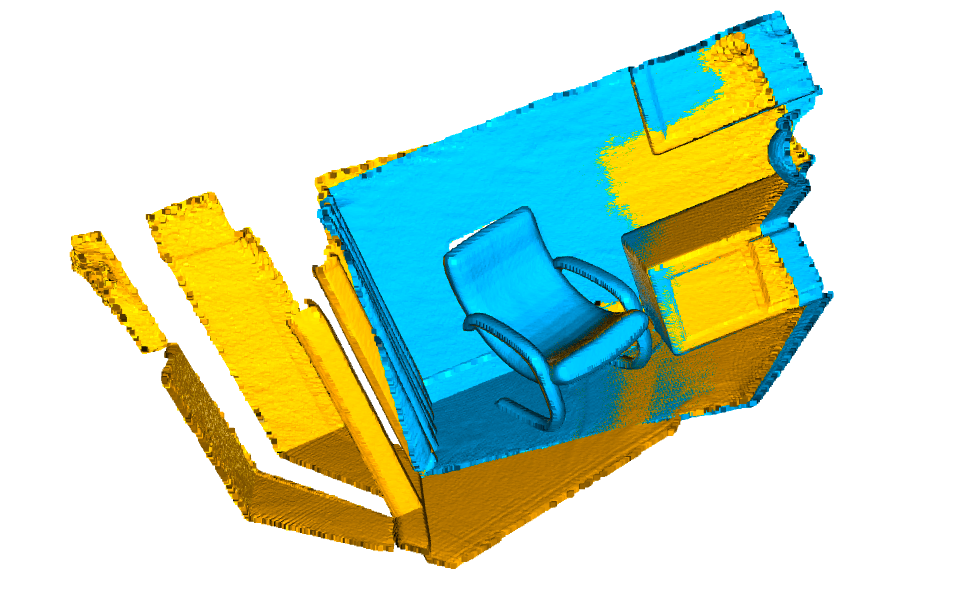
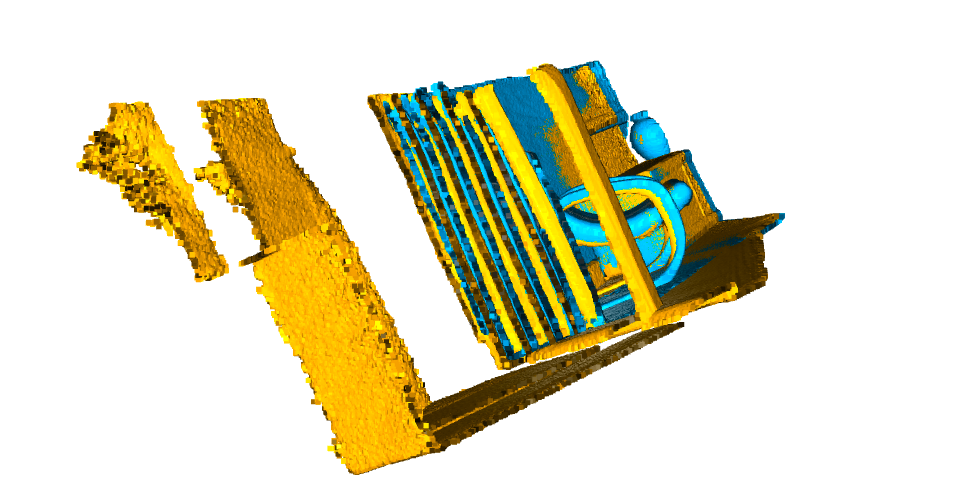
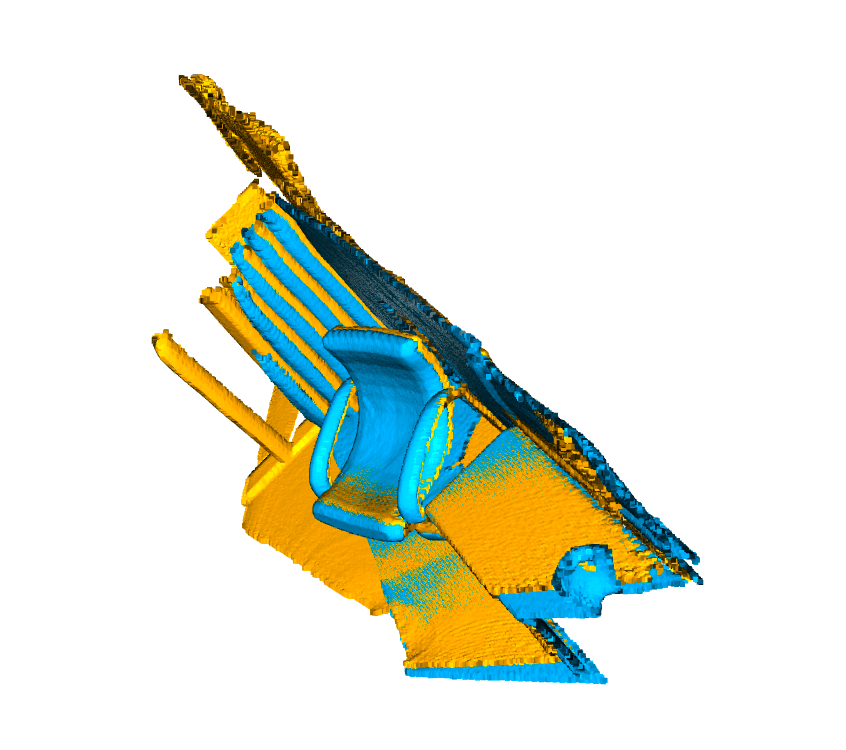
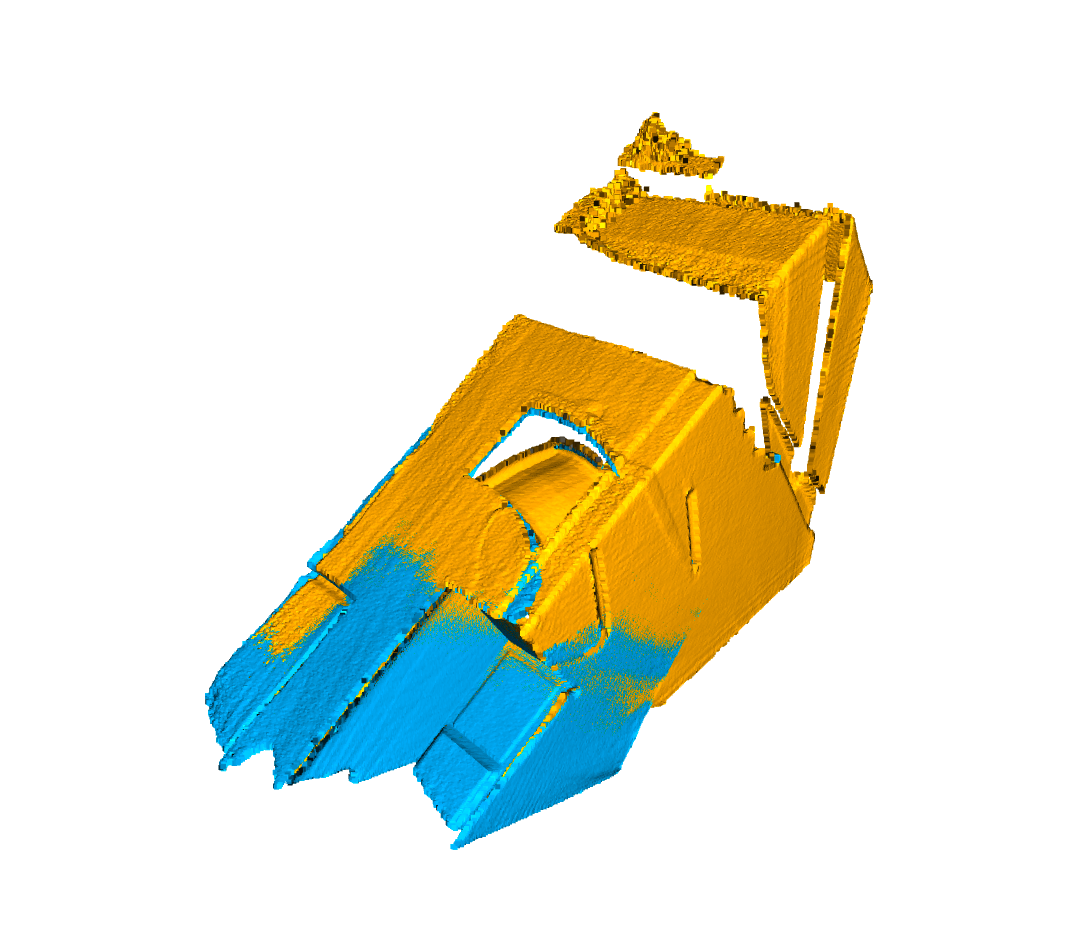

In [4]:
# 2. with the car1.ply and car2.ply files, perform global registration using RANSAC based on FPFH features.
source_car = o3d.io.read_point_cloud("global_registration/car1.ply")
target_car = o3d.io.read_point_cloud("global_registration/car2.ply")

voxel_size = 0.05

#downsampling the point clouds
source_down_car = source_car.voxel_down_sample(voxel_size)
target_down_car = target_car.voxel_down_sample(voxel_size)

# FPFH feature extraction
radius_normal = voxel_size * 2
radius_feature = voxel_size * 5

source_down_car.estimate_normals(
    o3d.geometry.KDTreeSearchParamHybrid(radius=radius_normal, max_nn=30))
target_down_car.estimate_normals(
    o3d.geometry.KDTreeSearchParamHybrid(radius=radius_normal, max_nn=30))

source_fpfh_car = o3d.pipelines.registration.compute_fpfh_feature(
    source_down_car,
    o3d.geometry.KDTreeSearchParamHybrid(radius=radius_feature, max_nn=100))
target_fpfh_car = o3d.pipelines.registration.compute_fpfh_feature(
    target_down_car,
    o3d.geometry.KDTreeSearchParamHybrid(radius=radius_feature, max_nn=100))

# RANSAC based global registration
distance_threshold = voxel_size * 1.5
point_to_point = o3d.pipelines.registration.TransformationEstimationPointToPoint(False)

o3d.utility.random.seed(0) #fixed seed for reproducibility
ransac_result_car = o3d.pipelines.registration.registration_ransac_based_on_feature_matching(
    source_down_car, target_down_car,
    source_fpfh_car, target_fpfh_car,
    True,
    distance_threshold,
    point_to_point)

print(ransac_result_car)
print("Transformation is:")
print(ransac_result_car.transformation)

draw_registrations(source_car, target_car, ransac_result_car.transformation, recolor = True)

RegistrationResult with fitness=9.919771e-01, inlier_rmse=3.251003e-02, and correspondence_set size of 3462
Access transformation to get result.
Transformation is:
[[-4.09846260e-02 -2.05452808e-03  9.99157665e-01  2.03455081e+00]
 [ 9.99028105e-01  1.61498812e-02  4.10125199e-02  2.09460639e+00]
 [-1.62205390e-02  9.99867471e-01  1.39063446e-03  1.30633300e-02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]


### Result
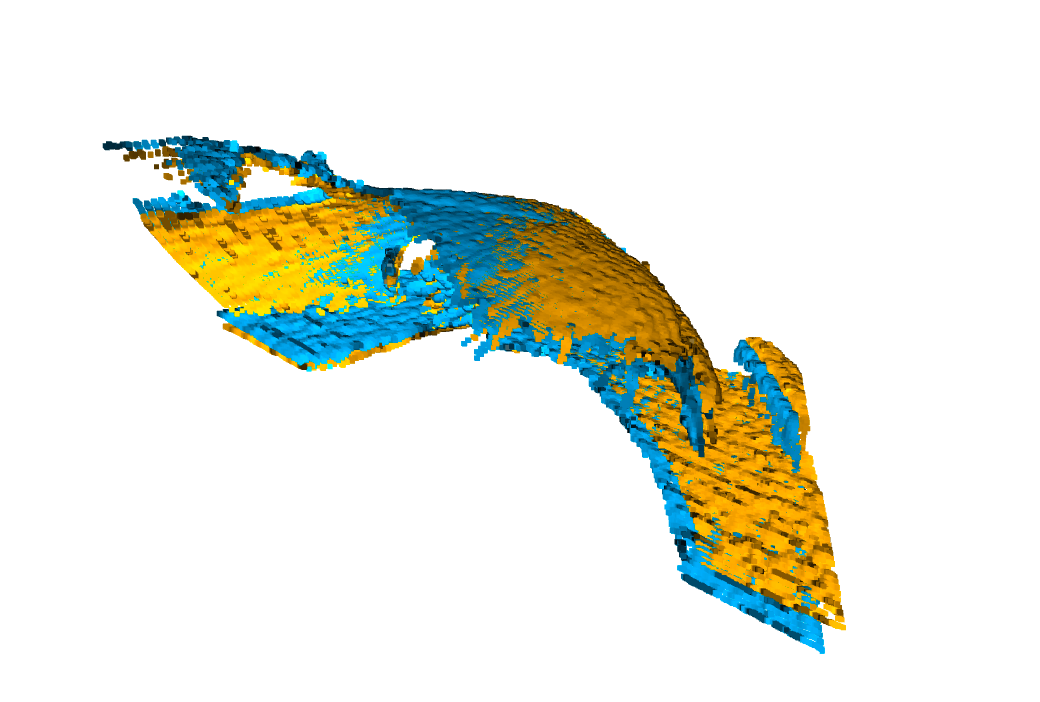
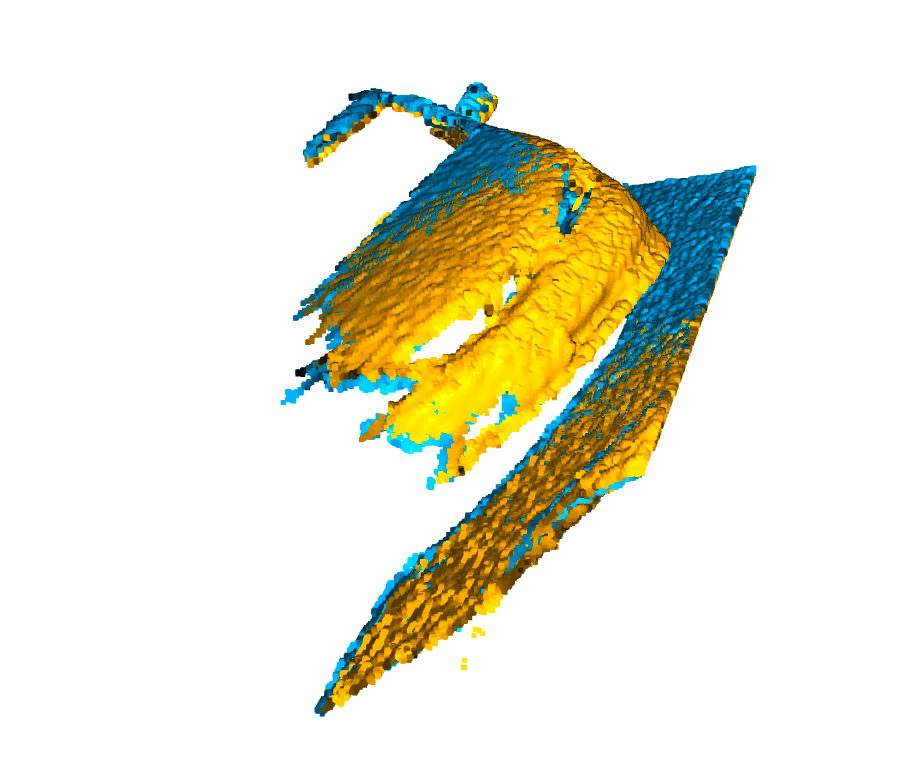
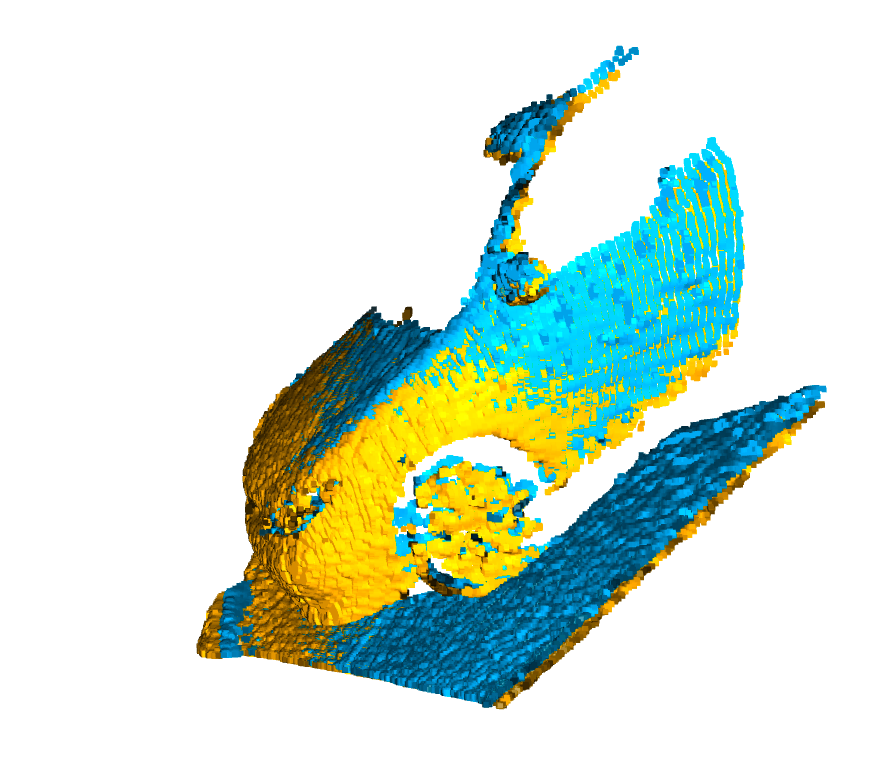
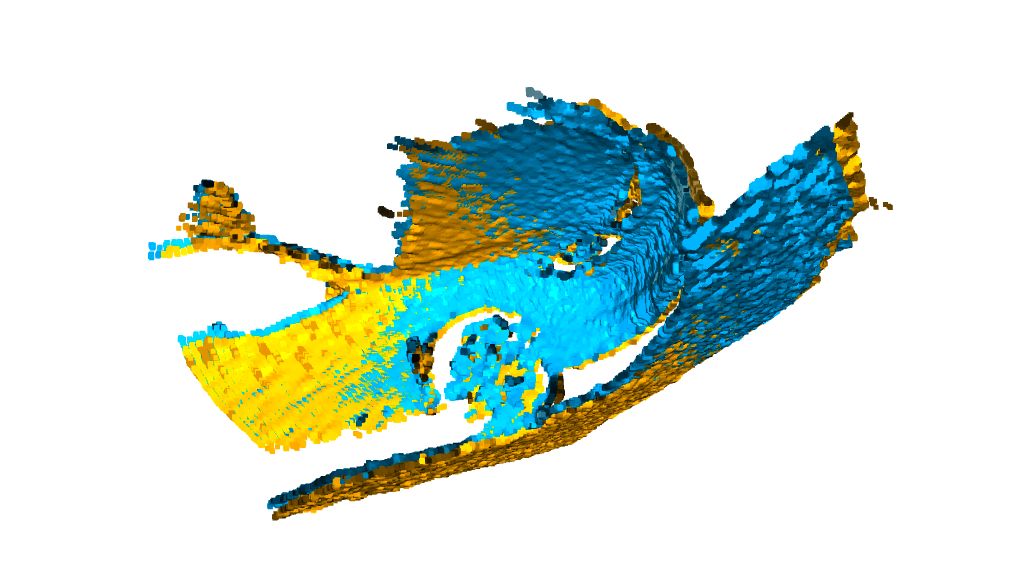

### Task 2 (Challange)